In [ ]:
# logs 1,2 correspond to reduced reward = 0
# log 3,4 correspond to reduced reward = 0.1

In [1]:
!pip install gymnasium

In [3]:
!pip install sb3-contrib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [sb3-contrib] [sb3-contrib]


In [25]:
!pip install pandas
!pip install matplotlib
!pip install -U tensorboard
!pip install -U tensorboard setuptools
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 153.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 216.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [statsmodels] [statsmodels]ta]


In [1]:
import sys
sys.path.append("/project_ghent/chronocooked")

In [4]:
from sb3_contrib import RecurrentPPO
from stable_baselines3 import PPO
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from tensorboard.backend.event_processing import event_accumulator

In [5]:
from singleagent.rl_environments.multitiming_production import MultiTimeProduction

In [6]:
import matplotlib as mpl

mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})


In [7]:
def plot_traj(obs_concat, act_concat, n_rows):
    arr = np.array(obs_concat)  # (200, 5, 3)

    n_rows = n_rows
    n_cols = len(arr) // n_rows# 40
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15,10))
    # fig, axes = plt.subplots(n_rows, n_cols, figsize=(10,2))
    
    for i, ax in enumerate(axes.flat):
        ax.imshow(arr[i], cmap = 'turbo', vmin=0, vmax=9, interpolation='nearest', aspect='auto')
        # ax.text(0.5, -0.6, str(act_concat[i]), fontsize=12)
        # ax.text(0.2, 5.6, str(reward_concat[i]), fontsize=12)
        if reward_concat[i] != 0:
            ax.set_title(f"A:{act_concat[i]} R:{reward_concat[i]}", fontsize=9, fontdict={"color":"red"})
        else:
            ax.set_title(f"A:{act_concat[i]}", fontsize=9)
        # x = ax.set_xticks(x_ticks, [f"{int(l[0])} , {str(l[1])}, {str(l[2])} " for l in zip(act_concat, range(len(act_concat)), reward_concat)], rotation =90, ha='right', fontsize=10)
    
        ax.axis('off')  # hide axes for clarity
    
    plt.tight_layout()
    plt.show()

In [7]:
# seeds
# map seed to each starting point
env = MultiTimeProduction(max_timesteps=200)
seeds = {(int(ax),int(ay)): -1 for ax, ay in zip(np.where(env.reset(seed=0)[0][:,:,0] ==0)[0],np.where(env.reset(seed=0)[0][:,:,0] ==0)[1])}
for s in range(1,30,1):
    ax, ay = np.where(env.reset(seed=s)[0][:,:,1] ==1)
    if seeds[int(ax[0]),int(ay[0])] == -1:
        seeds[int(ax[0]),int(ay[0])] = s
seeds

{(0, 0): 2,
 (1, 0): 14,
 (1, 1): 1,
 (1, 2): 3,
 (2, 1): 13,
 (2, 2): 7,
 (3, 0): 25,
 (3, 1): 9,
 (3, 2): 17,
 (4, 0): 5,
 (4, 1): 19,
 (4, 2): 20}

In [8]:
def get_min_ts_lastlevel(tb_event_file): # for the last level check if models learns task before max timesteps 
    # trainign timesteps needed for new anchor
    ea = event_accumulator.EventAccumulator(tb_event_file)
    ea.Reload()
    
    events = ea.Scalars("rollout/ep_rew_mean")
    
    steps = np.array([e.step for e in events])
    rewards = np.array([e.value for e in events])
    
    drop_fraction = 0.20  # 20%
    
    end_reward = rewards[-1]
    start_idx = 0
    
    if end_reward >=0.8: # get the first timestep where performance drops below 80
        for i in range(len(rewards) - 2, -1, -1):
            if rewards[i] < 0.8:
                start_idx = i + 1
                break
    
    return steps[start_idx]

In [24]:
def get_cl_task_performance(lstm_size=125, ctrnn=False, td_lists=[[2,4,6,8,10]]):
    
    # delivery_counter_used_history = {}
    observation_history = {}
    action_history = {}
    reward_history = {}
    min_training_timesteps = {}
    models_history = {}
    event_files = {}
    rows=[]
       
    ent_coeff = 0
    timestep = 200
    g = 0.99
    for td_list in td_lists:
        # print(td_list)
        duration_list_id = "-".join(map(str, td_list))
        min_training_timesteps[duration_list_id] = {}
        event_files[duration_list_id] = {}
    
        for env_i in range(len(td_list)+1):
            if env_i==0:
                num_timers= 1
                td_subset_str = f"{td_list[0]}_env0" 
            else:
                num_timers = env_i
                td_subset_str = "-".join(map(str, td_list[0:num_timers]))

            # delivery_counter_used_history[anchors_subset_str] = {}
            models_history[td_subset_str] = {}
            observation_history[td_subset_str] = {}
            action_history[td_subset_str] = {}
            reward_history[td_subset_str] = {}
            
            for log in [1,2,3,4]:
    
                models_folder = "/project_ghent/chronocooked/singleagent/train/multitimer_tp_cl_exact_modelsv2"
                if lstm_size is None:
                    model_file = f"v5_cl_exact_multitimer{duration_list_id}_tp_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_mlp64_gamma{g}_logs{log}/"
                    model_label = "CNN"
                elif ctrnn:
                    model_file = f"v5_cl_exact_multitimer{duration_list_id}_tp_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_ctrnn{lstm_size}_mlp64_gamma{g}_logs{log}/"
                    model_label = f"CTRNN{lstm_size}"
                else:
                    model_file = f"v5_cl_exact_multitimer{duration_list_id}_tp_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_sharedlstm{lstm_size}_mlp64_gamma{g}_logs{log}/"
                    model_label = f"LSTM{lstm_size}"           
                try:
                    model_files = os.listdir(f"{models_folder}/{model_file}")
                    
                except:
                    print("no such dir",f"{models_folder}/{model_file}" )
                    continue
                    
                # get min timesteps needed for last level of curriculum leanring 
                tb_event_file = [f"{models_folder}/{model_file}/{mod_file}" for mod_file in model_files if "env" not in mod_file][0]
                min_ts_lastlevel = get_min_ts_lastlevel(tb_event_file)
                event_files[duration_list_id][log] = tb_event_file
                # print(min_ts_lastlevel)
                
                # get timesteps correspondign to transition to next level of curriculum learning 
                max_training_ts_envi = max([int(mod_file.split("env")[1].split("_")[1])  if ("env" in mod_file) and (mod_file.split("env")[1].split("_")[0] == str(env_i)) else 0 for mod_file in model_files])
                
                if (num_timers == len(td_list)) and (min_ts_lastlevel>1000):
                    min_training_timesteps[duration_list_id][log] =  min_training_timesteps[duration_list_id].get(log, []) + [min_ts_lastlevel]
                else:
                    min_training_timesteps[duration_list_id][log] =  min_training_timesteps[duration_list_id].get(log, []) + [max_training_ts_envi]
                
                # delivery_counter_used_history[anchors_subset_str][f"{log}-{max_training_ts_envi}"] = {}
                models_history[td_subset_str][f"{log}-{max_training_ts_envi}"] = {}
                observation_history[td_subset_str][f"{log}-{max_training_ts_envi}"] = {}
                action_history[td_subset_str][f"{log}-{max_training_ts_envi}"] = {}
                reward_history[td_subset_str][f"{log}-{max_training_ts_envi}"] = {}

                if env_i ==0:
                   env_test = MultiTimeProduction(oven_duration_list=td_list, max_timesteps=timestep, num_timers=1,
                                reduced_reward=0.1, overcooked_buffer=0, undercooked_buffer=0, undercooked_possible=False)
                else:
                    env_test = MultiTimeProduction(oven_duration_list=td_list, max_timesteps=timestep, num_timers=num_timers,
                                    reduced_reward=0, overcooked_buffer=0, undercooked_buffer=0, undercooked_possible=True)
                
                try:
                    if lstm_size is None:
                        model = PPO.load(f"{models_folder}/{model_file}/rl_model_env{env_i}_{max_training_ts_envi}_steps.zip", 
                                         env=env_test)
                    else:
                        model = RecurrentPPO.load(f"{models_folder}/{model_file}/rl_model_env{env_i}_{max_training_ts_envi}_steps.zip", env=env_test)
                except:
                    print(f"could not load model, {models_folder}/{model_file}/rl_model_env{env_i}_{max_training_ts_envi}_steps.zip")
                    continue 
                    
                # for td in range(1,td_list[num_timers-1]+2):
                # print(model, td_list[:num_timers-1],td_list)
                for td in td_list[:num_timers]:
                    # print(td)
                    

                    if env_i ==0:
                       env_test = MultiTimeProduction(oven_duration_list=td_list, max_timesteps=timestep, 
                                                      num_timers=1, reduced_reward=0.1, overcooked_buffer=0, 
                                                      undercooked_buffer=0, undercooked_possible=False)
                    else:
                        env_test = MultiTimeProduction(oven_duration_list=td_list, max_timesteps=timestep,
                                                         num_timers=num_timers, reduced_reward=0, overcooked_buffer=0, 
                                                         undercooked_buffer=0, undercooked_possible=True)
                    

                    td_observations = []
                    td_actions = []
                    td_rewards = []
                    
    
                    for seed in seeds.values():    
                        obs, _ = env_test.reset(seed=seed, oven_duration=td)
                        visual_obs = np.sum(obs,axis=2)
                        obs_concat = [visual_obs]
                        act_concat = []
                        oven_timers_concat = []
                        reward_concat = []
                        # print("oven timers", env_test.oven1_timer, env_test.oven2_timer)
                        rewards=0
                        states = None
                        
                        for i in range(timestep + 2):
                            # obs = obs + 300
                            action, states = model.predict(obs, state=states, deterministic=True) 
                            act_concat.append(action)
                            # print(visual_obs)
                            # print("action",action)
                            obs, reward, done, _ ,_= env_test.step(action)
                            visual_obs = np.sum(obs,axis=2)
                            obs_concat.append(visual_obs)
                        
                            # print("reward",reward)
                            # print("oven timer", env_test.oven_timer)
                            
                            rewards += reward
                            reward_concat.append(reward)
                            oven_timers_concat.append(env_test.oven_timer)
                            
                            if done:
                                # print(rows)
                                reward_concat.append(reward)
                                act_concat.append(0)
                                timing_actions = [a for a, t in zip(act_concat, oven_timers_concat) if t != -1]
                                
                                td_observations.append(obs_concat)
                                td_actions.append(act_concat)
                                td_rewards.append(reward_concat)
                                rows.append({"duration_list_id":duration_list_id,  "model":model_label,
                                             "td_subset_str":td_subset_str, "Cl_stage":env_i, "num_timers":num_timers,"TD":td, 
                                            "log":log, "seed":seed,
                                            "reward":reward, "oven_off_time":env_test.oven_off_time, 
                                            "delta_oven_off":env_test.oven_off_time - td, "timing_actions":timing_actions
                                            
                                            })
                                
                                # obs,_ = env_test.reset()                    
                                # print("short_duration", short_duration, "long_duration", long_duration, "rewards",rewards, "delivery counter", env_test.delivery_counter_used, i+1)
                                break
                    observation_history[td_subset_str][f"{log}-{max_training_ts_envi}"][td] = td_observations
                    action_history[td_subset_str][f"{log}-{max_training_ts_envi}"][td] = td_actions
                    reward_history[td_subset_str][f"{log}-{max_training_ts_envi}"][td] = td_rewards
                models_history[td_subset_str][f"{log}-{max_training_ts_envi}"] = dict(model.policy.named_parameters())
                    
    
    performance_history_df = pd.DataFrame(rows)
    return performance_history_df, min_training_timesteps , event_files, models_history, observation_history, action_history, reward_history


In [35]:
performance_history_df125, min_training_timesteps125, event_files125, models_history125, observation_history125, action_history125, reward_history125 = get_cl_task_performance(lstm_size=125, ctrnn=False, td_lists=[[2,4,6,8,10],[3,6,9,12,15]]) 

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
could not load model, /project_ghent/chronocooked/singleagent/train/multitim

In [36]:
performance_history_df256, min_training_timesteps256, event_files256, models_history256, observation_history256, action_history256, reward_history256 = get_cl_task_performance(lstm_size=256, ctrnn=False, td_lists=[[2,4,6,8,10],[3,6,9,12,15]]) 

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
could not load model, /project_ghent/chronocooked/singleagent/train/multitimer_tp_cl_exact_modelsv2/v5_cl_exact_multitimer2-4-6-8-10_tp_cnnout64_ts200_entcoef0_nepoch20_sharedlstm256_mlp64_gamma0.99_logs3//rl_model_env2_0_steps.zi

In [25]:
performance_history_df8, min_training_timesteps8, event_files8, models_history8, observation_history8, action_history8, reward_history8 = get_cl_task_performance(lstm_size=8, ctrnn=False,td_lists=[[2,4,6,8,10],[3,6,9,12,15]]) 

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
could not load model, /project_ghent/chronocooked/singleagent/train/multitimer_tp_cl_exact_modelsv2/v5_cl_exact_multitimer2-4-6-8-10_tp_cnnout64_ts200_entcoef0_nepoch20_sharedlstm8_mlp64_gamma0.99_logs1//rl_model_env2_0_steps.zip
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
could not load model, /project_ghent/chronocooked/singleagent/train/multitime

In [37]:
performance_history_df_ctrnn8, min_training_timesteps_ctrnn8, event_files_ctrnn8, models_history_ctrnn8, observation_history_ctrnn8, action_history_ctrnn8, reward_history_ctrnn8 = get_cl_task_performance(lstm_size=8, ctrnn=True, td_lists=[[2,4,6,8,10],[3,6,9,12,15]]) 

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
could not load model, /project_ghent/chronocooked/singleagent/train/multitimer_tp_cl_exact_modelsv2/v5_cl_exact_multitimer2-4-6-8-10_tp_cnnout64_ts200_entcoef0_nepoch20_ctrnn8_mlp64_gamma0.99_logs1//rl_model_env1_0_steps.zip
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
could not load model, /project_ghent/chronocooked/singleagent/train/multitimer_tp_cl_exact_modelsv2/v5_cl_exact_multitimer2-4-6-8-10_tp_cnnout64_ts200_entcoef0_nepoch20_ctrnn8_mlp64_gamma0.99_logs4//rl_model_env1_0_steps.zip
could not load model, /project_ghent/chronocooked/singleagent/train/multitimer_tp_cl_exa

In [38]:
performance_history_df_ctrnn125, min_training_timesteps_ctrnn125, event_files_ctrnn125, models_history_ctrnn125, observation_history_ctrnn125, action_history_ctrnn125, reward_history_ctrnn125 = get_cl_task_performance(lstm_size=125, ctrnn=True, td_lists=[[2,4,6,8,10],[3,6,9,12,15]]) 

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
could not load model, /project_ghent/chronocooked/singleagent/train/multitimer_tp_cl_exact_modelsv2/v5_cl_exact_multitimer2-4-6-8-10_tp_cnnout64_ts200_entcoef0_nepoch20_ctrnn125_mlp64_gamma0.99_logs1//rl_model_env2_0_steps.zip
could not load model, /project_ghent/chronocooked/singleagent/train/multitimer_tp_cl_exact_modelsv2/v5_cl_exact_multitimer2-4-6-8-10_tp_cnnout64_ts200_entcoe

In [54]:
performance_history_df_ctrnn125

,duration_list_id,model,td_subset_str,Cl_stage,num_timers,TD,log,seed,reward,oven_off_time,delta_oven_off
0,2-4-6-8-10,CTRNN125,2_env0,0,1,2,1,2,1,2,0
1,2-4-6-8-10,CTRNN125,2_env0,0,1,2,1,14,1,2,0
2,2-4-6-8-10,CTRNN125,2_env0,0,1,2,1,1,1,2,0
3,2-4-6-8-10,CTRNN125,2_env0,0,1,2,1,3,1,2,0
4,2-4-6-8-10,CTRNN125,2_env0,0,1,2,1,13,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...
139,3-6-9-12-15,CTRNN125,3_env0,0,1,3,4,9,0,-1,-4
140,3-6-9-12-15,CTRNN125,3_env0,0,1,3,4,17,0,-1,-4
141,3-6-9-12-15,CTRNN125,3_env0,0,1,3,4,5,0,-1,-4
142,3-6-9-12-15,CTRNN125,3_env0,0,1,3,4,19,0,-1,-4


In [39]:
performance_history_df_ctrnn256, min_training_timesteps_ctrnn256, event_files_ctrnn256, models_history_ctrnn256, observation_history_ctrnn256, action_history_ctrnn256, reward_history_ctrnn256 = get_cl_task_performance(lstm_size=256, ctrnn=True, td_lists=[[2,4,6,8,10],[3,6,9,12,15]]) 

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
could not load model, /project_ghent/chronocooked/singleagent/train/multitimer_tp_cl_exact_modelsv2/v5_cl_exact_multitimer2-4-6-8-10_tp_cnnout64_ts200_entcoef0_nepoch20_ctrnn256_mlp64_gamma0.99_logs1//rl_model_env2_0_steps.zip
could not load model, /project_ghent/chronocooked/singleagent/train/multitimer_tp_cl_exact_modelsv2/v5_cl_exact_multitimer2-4-6-8-10_tp_cnnout64_ts200_entcoe

In [40]:
performance_history_df_cnn, min_training_timesteps_cnn, event_files_ctrnn8, models_history_cnn, observation_history_cnn, action_history_cnn, reward_history_cnn = get_cl_task_performance(lstm_size=None, ctrnn=False, td_lists=[[2,4,6,8,10],[3,6,9,12,15]]) 

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
could not load model, /project_ghent/chronocooked/singleagent/train/multitimer_tp_cl_exact_modelsv2/v5_cl_exact_multitimer2-4-6-8-10_tp_cnnout64_ts200_entcoef0_nepoch20_mlp64_gamma0.99_logs1//rl_model_env2_0_steps.zip
could not load model, /project_ghent/chronocooked/singleagent/train/multitimer_tp_cl_exact_modelsv2/v5_cl_exact_multitimer2-4-6-8-10_tp_cnnout64_ts200_entcoef0_nepoch

In [19]:
# min_training_timesteps125,
min_training_timesteps_ctrnn125, min_training_timesteps8, min_training_timesteps_ctrnn8

({'2-4-6-8-10': {1: [441000, 1750000, 0, 0, 0, 0],
   2: [977000, 1750000, 0, 0, 0, 0],
   3: [111000, 1750000, 0, 0, 0, 0],
   4: [78000, 1750000, 0, 0, 0, 0]},
  '3-6-9-12-15': {1: [1750000, 0, 0, 0, 0, 0],
   2: [1750000, 0, 0, 0, 0, 0],
   3: [1750000, 0, 0, 0, 0, 0],
   4: [1750000, 0, 0, 0, 0, 0]}},
 {'2-4-6-8-10': {1: [104000, 1750000, 0, 0, 0, 0],
   2: [124000, 147000, 178000, 186000, 192000, 1750000],
   3: [72000, 1750000, 0, 0, 0, 0],
   4: [52000, 169000, 201000, 239000, 316000, 1750000]},
  '3-6-9-12-15': {1: [132000, 1750000, 0, 0, 0, 0],
   2: [39000, 1750000, 0, 0, 0, 0],
   3: [66000, 1750000, 0, 0, 0, 0],
   4: [292000, 1750000, 0, 0, 0, 0]}},
 {'2-4-6-8-10': {1: [1750000, 0, 0, 0, 0, 0],
   2: [145000, 1750000, 0, 0, 0, 0],
   3: [877000, 1750000, 0, 0, 0, 0],
   4: [1750000, 0, 0, 0, 0, 0]},
  '3-6-9-12-15': {1: [1750000, 0, 0, 0, 0, 0],
   2: [1750000, 0, 0, 0, 0, 0],
   3: [1750000, 0, 0, 0, 0, 0],
   4: [1750000, 0, 0, 0, 0, 0]}})

In [23]:
performance_history_df8

,duration_list_id,model,td_subset_str,Cl_stage,num_timers,TD,log,seed,reward,oven_off_time,delta_oven_off
0,2-4-6-8-10,LSTM8,2-4,2,2,2,2,2,1,2,0
1,2-4-6-8-10,LSTM8,2-4,2,2,2,2,14,1,2,0
2,2-4-6-8-10,LSTM8,2-4,2,2,2,2,1,1,2,0
3,2-4-6-8-10,LSTM8,2-4,2,2,2,2,3,1,2,0
4,2-4-6-8-10,LSTM8,2-4,2,2,2,2,13,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...
235,2-4-6-8-10,LSTM8,2-4-6-8-10,5,5,8,4,9,0,-1,-9
236,2-4-6-8-10,LSTM8,2-4-6-8-10,5,5,8,4,17,0,-1,-9
237,2-4-6-8-10,LSTM8,2-4-6-8-10,5,5,8,4,5,0,-1,-9
238,2-4-6-8-10,LSTM8,2-4-6-8-10,5,5,8,4,19,0,-1,-9


In [57]:
performance_history_df_ctrnn125.groupby(["td_subset_str","log"])["oven_off_time"].describe()

count      mean       std  min  25%  50%  75%  max
td_subset_str log                                                    
2             1     12.0 -0.833333  0.577350 -1.0 -1.0 -1.0 -1.0  1.0
              2     12.0 -1.000000  0.000000 -1.0 -1.0 -1.0 -1.0 -1.0
              3     12.0 -1.000000  0.000000 -1.0 -1.0 -1.0 -1.0 -1.0
              4     12.0 -1.000000  0.000000 -1.0 -1.0 -1.0 -1.0 -1.0
2_env0        1     12.0  1.500000  1.167748 -1.0  2.0  2.0  2.0  2.0
              2     12.0  2.000000  0.000000  2.0  2.0  2.0  2.0  2.0
              3     12.0  1.750000  0.866025 -1.0  2.0  2.0  2.0  2.0
              4     12.0 -1.000000  0.000000 -1.0 -1.0 -1.0 -1.0 -1.0
3_env0        1     12.0 -1.000000  0.000000 -1.0 -1.0 -1.0 -1.0 -1.0
              2     12.0 -1.000000  0.000000 -1.0 -1.0 -1.0 -1.0 -1.0
              3     12.0 -1.000000  0.000000 -1.0 -1.0 -1.0 -1.0 -1.0
              4     12.0 -1.000000  0.000000 -1.0 -1.0 -1.0 -1.0 -1.0

In [17]:
performance_history_df125[(performance_history_df125["log"]==1) & (performance_history_df125["td_subset_str"]=="2-4")]

,duration_list_id,model,td_subset_str,Cl_stage,num_timers,TD,log,seed,reward,oven_off_time,delta_oven_off
72,2-4-6-8-10,LSTM125,2-4,2,2,1,1,2,0,-1,-2
73,2-4-6-8-10,LSTM125,2-4,2,2,1,1,14,0,-1,-2
74,2-4-6-8-10,LSTM125,2-4,2,2,1,1,1,0,-1,-2
75,2-4-6-8-10,LSTM125,2-4,2,2,1,1,3,0,1,0
76,2-4-6-8-10,LSTM125,2-4,2,2,1,1,13,0,1,0
77,2-4-6-8-10,LSTM125,2-4,2,2,1,1,7,0,1,0
78,2-4-6-8-10,LSTM125,2-4,2,2,1,1,25,0,1,0
79,2-4-6-8-10,LSTM125,2-4,2,2,1,1,9,0,1,0
80,2-4-6-8-10,LSTM125,2-4,2,2,1,1,17,0,1,0
81,2-4-6-8-10,LSTM125,2-4,2,2,1,1,5,0,15,14


In [81]:
performance_history_df125[performance_history_df125["num_timers"]==1]

,duration_list_id,model,td_subset_str,Cl_stage,num_timers,TD,log,seed,reward,oven_off_time,delta_oven_off
0,2-4-6-8-10,LSTM125,2_env0,0,1,1,1,2,1.0,1,0
1,2-4-6-8-10,LSTM125,2_env0,0,1,1,1,14,1.0,1,0
2,2-4-6-8-10,LSTM125,2_env0,0,1,1,1,1,1.0,1,0
3,2-4-6-8-10,LSTM125,2_env0,0,1,1,1,3,1.0,1,0
4,2-4-6-8-10,LSTM125,2_env0,0,1,1,1,13,1.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
139,2-4-6-8-10,LSTM125,2,1,1,3,2,9,0.1,2,-1
140,2-4-6-8-10,LSTM125,2,1,1,3,2,17,0.1,2,-1
141,2-4-6-8-10,LSTM125,2,1,1,3,2,5,0.1,2,-1
142,2-4-6-8-10,LSTM125,2,1,1,3,2,19,0.1,2,-1


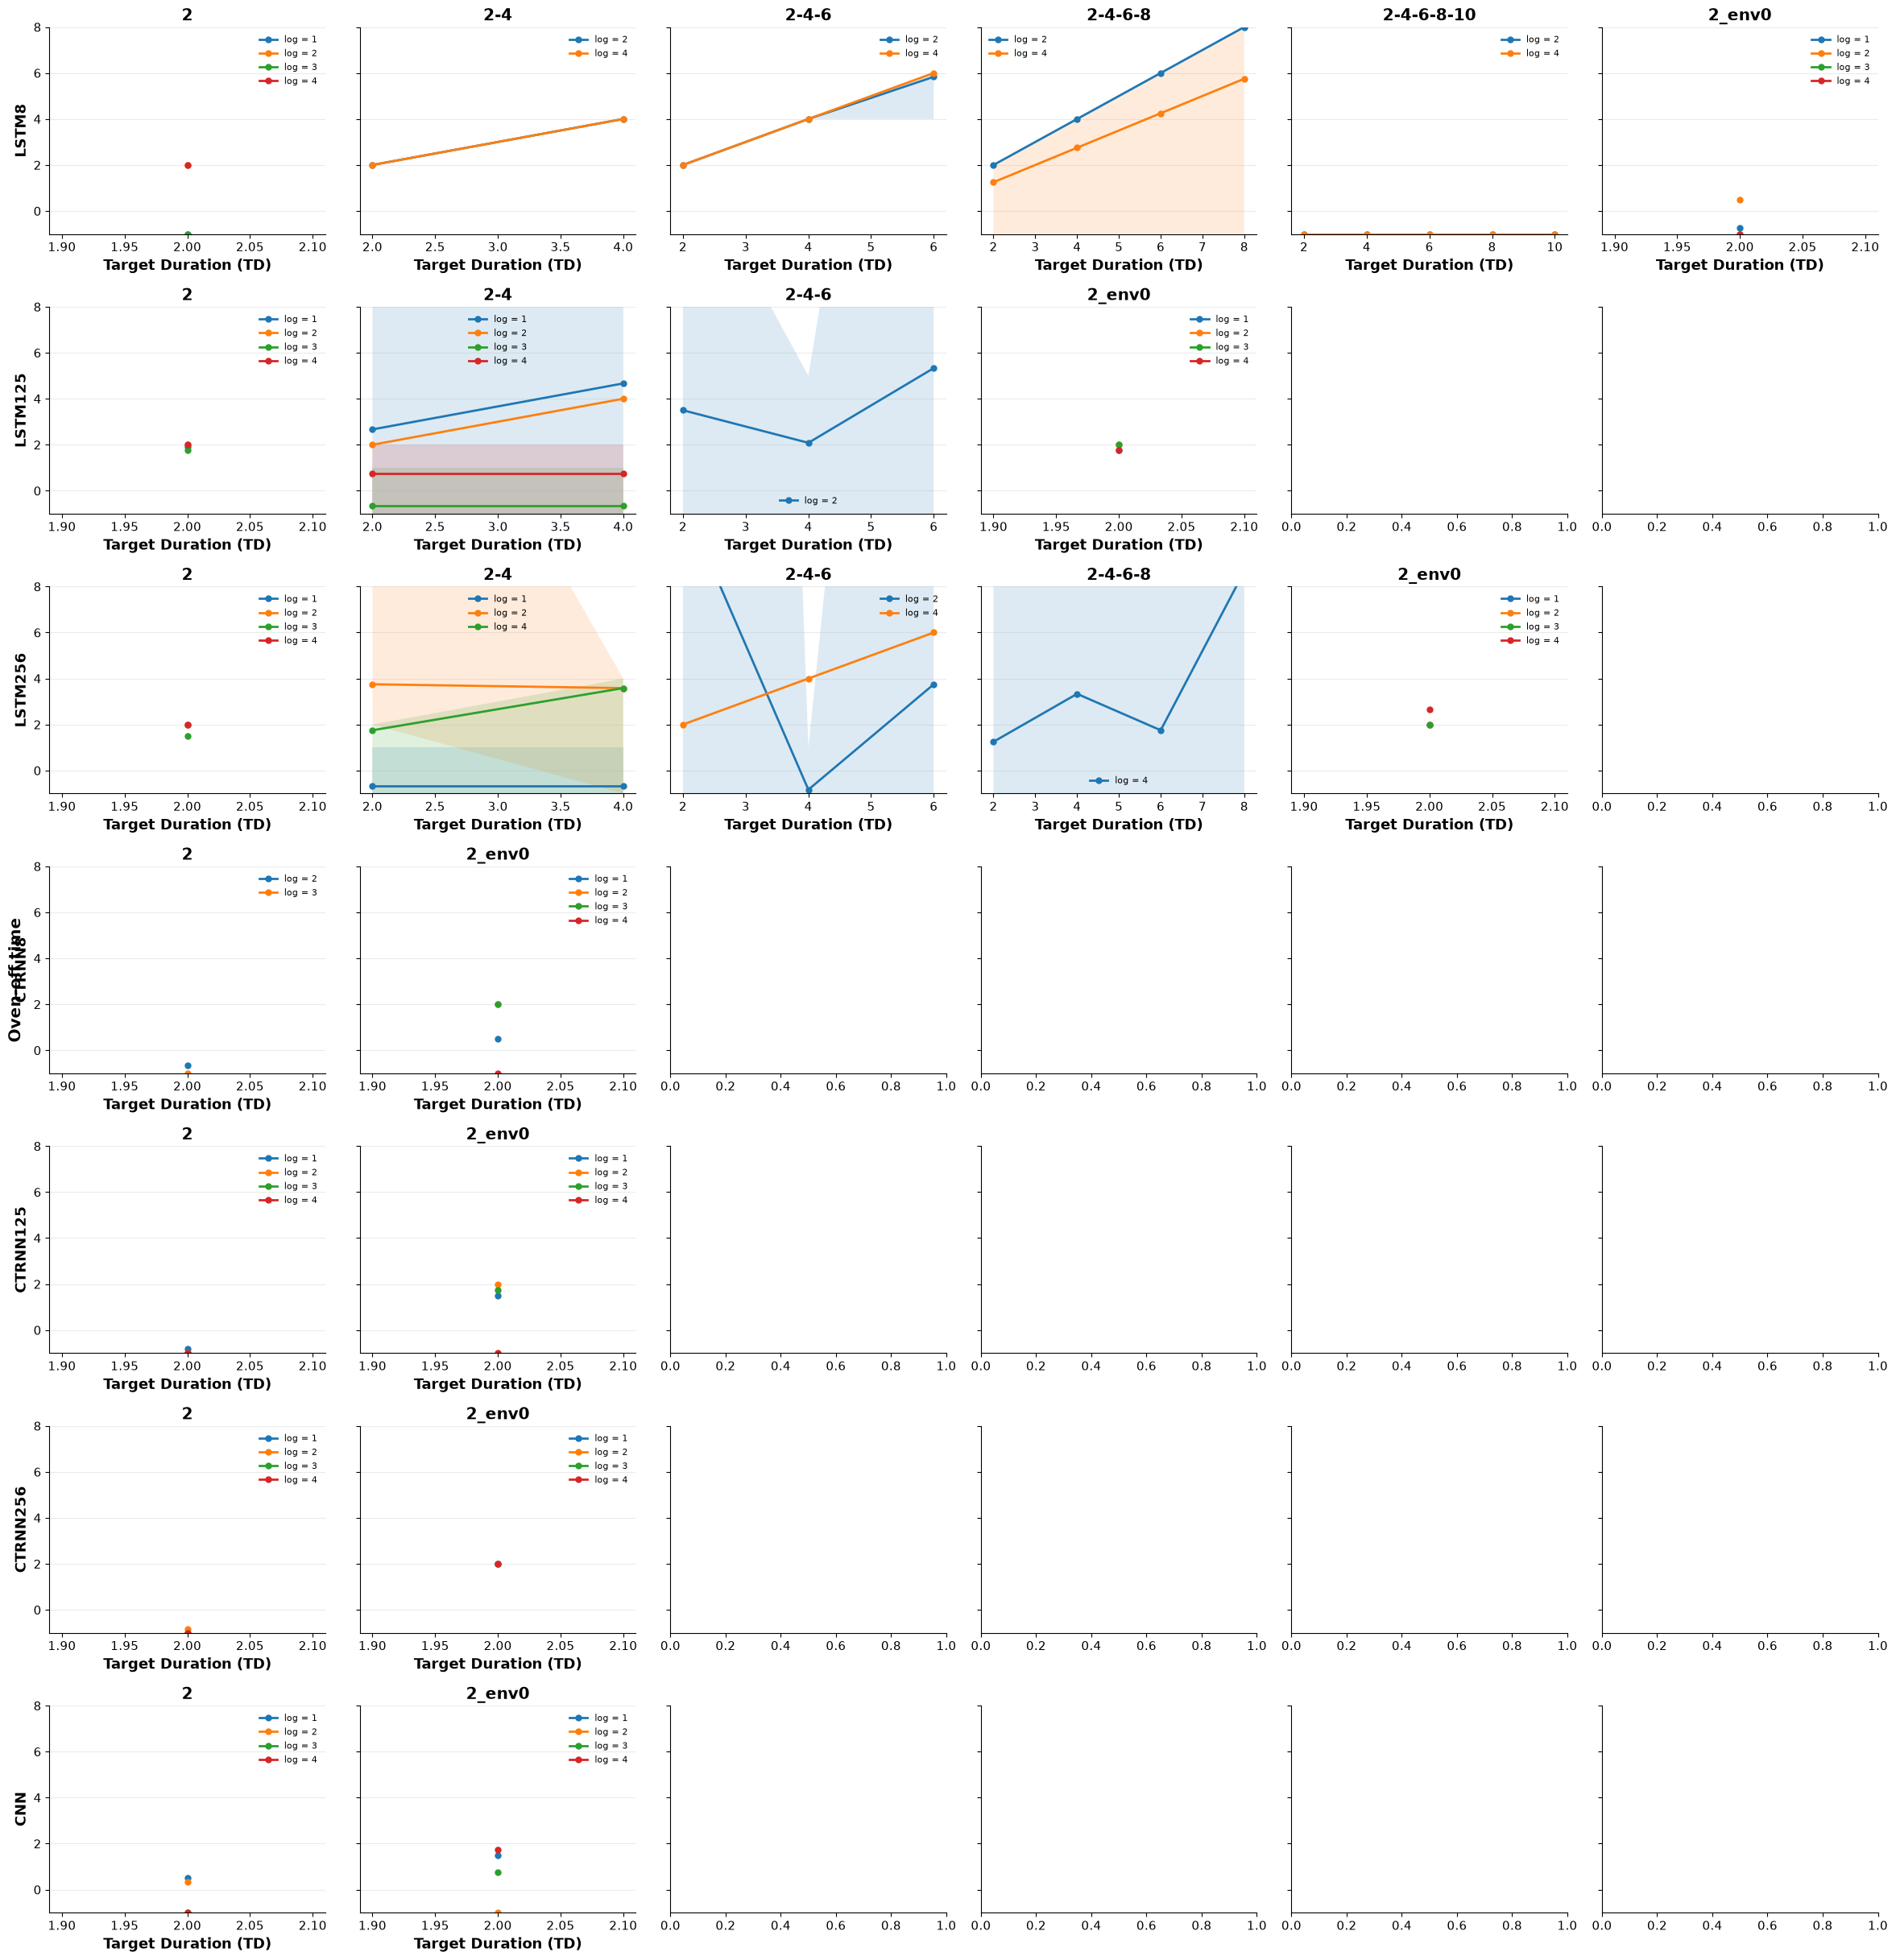

In [20]:
results_list = [
    performance_history_df8, 
    performance_history_df125, performance_history_df256,
               performance_history_df_ctrnn8, performance_history_df_ctrnn125, performance_history_df_ctrnn256, performance_history_df_cnn]


model_names = [
    "LSTM8",
    "LSTM125",
    "LSTM256",
    "CTRNN8",
    "CTRNN125",
    "CTRNN256",
    "CNN"
]

# results_list = [ performance_history_df125, performance_history_df256,
#                performance_history_df_ctrnn8, performance_history_df_ctrnn125, performance_history_df_ctrnn256]
# model_names = [
    
#     "LSTM125",
#     "LSTM256",
#     "CTRNN8",
#     "CTRNN125",
#     "CTRNN256",
# ]

# results_list = [performance_history_df125,
#                performance_history_df_ctrnn125, performance_history_df_cnn]


# model_names = [

#     "LSTM125",
#     "CTRNN125",

#     "CNN"
# ]

# Get all td_subsets across all results first
all_td_subsets = sorted(
    set(
        td_subset
        for performance_df in results_list 
        for td_subset in performance_df["td_subset_str"].unique() 
    )
)

n_rows = len(results_list)
n_cols = len(all_td_subsets) 

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3.5 * n_rows),
    sharey=True,
    squeeze=False
)
 

for row_i, performance_df in enumerate(results_list):

    performance_df =performance_df[performance_df["Cl_stage"]>=0]
    performance_df=performance_df[performance_df["TD"].isin([2,4,6,8,10])]
    summary = (
        performance_df.groupby(["td_subset_str", "log", "TD"])["oven_off_time"]
          .agg(
              mean="mean",
              min="min",
              max="max"
          )
          .reset_index()
    )
    
    # ------------------------------------------------------------
    # Plot: one column per td_subset_str
    # ------------------------------------------------------------
    
    td_subsets = sorted(summary["td_subset_str"].unique())
    

    
    for col_i, td_subset in enumerate(td_subsets):
        if len(results_list) ==1:
            ax=axes[col_i]
        else:
            ax=axes[row_i, col_i]
    
        subset = summary[
            summary["td_subset_str"] == td_subset
        ]
    
        # One line for each log
        for log in sorted(subset["log"].unique()):
    
            data = (
                subset[subset["log"] == log]
                .sort_values("TD")
            )
    
            x = data["TD"].to_numpy()
            mean = data["mean"].to_numpy()
            lower = data["min"].to_numpy()
            upper = data["max"].to_numpy()
    
            # Min-max shaded region across seeds
            ax.fill_between(
                x,
                lower,
                upper,
                alpha=0.15
            )
    
            # Mean across seeds
            ax.plot(
                x,
                mean,
                marker="o",
                linewidth=2,
                markersize=5,
                label=f"log = {log}"
            )
    
        ax.set_title(
            td_subset,
            fontweight="bold"
        )
    
        ax.set_xlabel(
            "Target Duration (TD)",
            fontweight="bold"
        )
    
        ax.grid(
            axis="y",
            alpha=0.25
        )
    
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    
        ax.legend(
            frameon=False,
            fontsize=8
        )
        ax.set_ylim(-1,8)
    axes[row_i, 0].set_ylabel(
    model_names[row_i],
    fontweight="bold"
    )


fig.supylabel(
    "Oven-off time",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# rewards across cl stages


Valid td_subset_str values:
['2', '2-4', '2-4-6', '2-4-6-8', '2-4-6-8-10']

Valid td_subset_str values:
['3', '3-6']


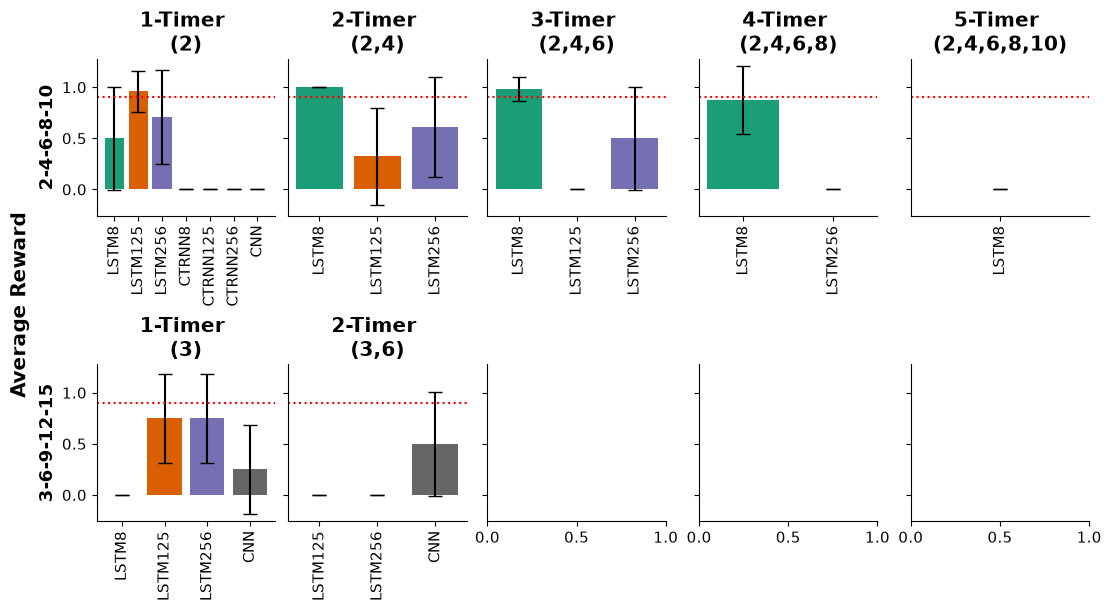

In [23]:
results_list = [
    performance_history_df8,
    performance_history_df125,
    performance_history_df256,
    performance_history_df_ctrnn8,
    performance_history_df_ctrnn125,
    performance_history_df_ctrnn256,
    performance_history_df_cnn
]

model_names = [
    "LSTM8",
    "LSTM125",
    "LSTM256",
    "CTRNN8",
    "CTRNN125",
    "CTRNN256",
    "CNN"
]

# --------------------------------------------------
# Calculate mean + SD for each model and td_subset_str
# --------------------------------------------------

summary = []

for df, model in zip(results_list, model_names):
    for duration_list in df["duration_list_id"].unique():
        parts = duration_list.split("-")
        
        td_sub_strs = ["-".join(parts[:i]) for i in range(1, len(parts) + 1)]

        for td in td_sub_strs:
    
            filtered = df[
                (df["duration_list_id"] == duration_list) &
                (df["td_subset_str"] == td)
            ]

            rewards = filtered["reward"].dropna()
    
            # Only include if this model has data for this td
            if not rewards.empty:
                summary.append({
                    "model": model,
                    "duration_list": duration_list,
                    "td_subset_str": td,
                    "mean_reward": rewards.mean(),
                    "sd_reward": rewards.std(),
                    "n": rewards.size
                })

summary_df = pd.DataFrame(summary)
summary_df["architecture"] = (
    summary_df["model"].str.extract(r"^(LSTM|CTRNN|CNN)")
)
duration_lists = summary_df["duration_list"].unique()
n_cols = max(len(x.split("-")) for x in duration_lists)
# n_cols = 2

fig, axes = plt.subplots(
    len(duration_lists), n_cols,
    figsize=(11,6),
    constrained_layout=True,
    squeeze=False,
    sharey=True
)

# colors = plt.cm.Dark2(np.linspace(0, 1, len(model_names)))
cmap = plt.cm.Dark2
colors = [cmap(i) for i in np.linspace(0,1, len(model_names))]

color_map = dict(zip(model_names, colors))

for row, duration_list in enumerate(duration_lists):

    parts = duration_list.split("-")
    td_sub_strs = ["-".join(parts[:i]) for i in range(1, len(parts) + 1)]

    valid_td_sub_strs = [
    td for td in td_sub_strs
    if td in summary_df["td_subset_str"].values
    ]

    # valid_td_sub_strs = [
    # td for td in td_sub_strs
    # if len(td.split("-"))>3
    # ]
    print("\nValid td_subset_str values:")
    print(valid_td_sub_strs)

    for col, td in enumerate(valid_td_sub_strs):

        ax = axes[row, col]

        plot_df = summary_df[
            (summary_df["duration_list"] == duration_list) &
            (summary_df["td_subset_str"] == td)
        ].copy()

        plot_df["model"] = pd.Categorical(
            plot_df["model"],
            categories=model_names,
            ordered=True
        )
        plot_df = plot_df.sort_values("model")

        ax.bar(
            plot_df["model"],
            plot_df["mean_reward"],
            yerr=plot_df["sd_reward"],
            capsize=5,
            color=[color_map[m] for m in plot_df["model"].unique()],
            linewidth=0.8
        )

        ax.axhline(0.9, color="red", linestyle=":", linewidth=1.5)
        ax.set_title(f"{len(td.split("-"))}-Timer \n({",".join([ti for ti in td.split("-")])})", fontweight="bold")
        ax.tick_params(axis="x", rotation=90)

    # Hide unused columns
    for col in range(len(td_sub_strs), n_cols):
        axes[row, col].axis("off")

    axes[row, 0].set_ylabel(duration_list, fontweight="bold")

fig.supylabel("Average Reward", fontweight="bold")
plt.savefig("multitimer_task_performance_exact.pdf",bbox_inches="tight" )
plt.show()


In [35]:
# results_list = [
#     performance_history_df8,
#     performance_history_df125,
#     performance_history_df256,
#     performance_history_df_ctrnn8,
#     performance_history_df_ctrnn125,
#     performance_history_df_ctrnn256,
#     performance_history_df_cnn
# ]

# model_names = [
#     "LSTM8",
#     "LSTM125",
#     "LSTM256",
#     "CTRNN8",
#     "CTRNN125",
#     "CTRNN256",
#     "CNN"
# ]

# # --------------------------------------------------
# # Target td_subset_str values
# # --------------------------------------------------

# td_sub_strs = [
#     "2",
#     "2-4",
#     "2-4-6",
#     "2-4-6-8",
#     "2-4-6-8-10"
# ]

# # --------------------------------------------------
# # Calculate mean + SD for each model and td_subset_str
# # --------------------------------------------------

# summary = []

# for df, model in zip(results_list, model_names):

#     for td in td_sub_strs:

#         filtered = df[df["td_subset_str"] == td]

#         # Only include if this model has data for this td
#         if not filtered["reward"].dropna().empty:
#             summary.append({
#                 "model": model,
#                 "td_subset_str": td,
#                 "mean_reward": filtered["reward"].mean(),
#                 "sd_reward": filtered["reward"].std(),
#                 "n": filtered["reward"].notna().sum()
#             })

# summary_df = pd.DataFrame(summary)
# # summary_df["architecture"] = summary_df["model"].str.extract(r"^(LSTM|CTRNN)")

# # --------------------------------------------------
# # Keep only td_subset_str values for which at least
# # one model has data
# # --------------------------------------------------

# valid_td_sub_strs = [
#     td for td in td_sub_strs
#     if td in summary_df["td_subset_str"].values
# ]

# print("\nValid td_subset_str values:")
# print(valid_td_sub_strs)


# # --------------------------------------------------
# # Plot
# # --------------------------------------------------

# n_cols = len(valid_td_sub_strs)

# fig, axes = plt.subplots(
#     1,
#     n_cols,
#     figsize=(12, 3),
#     constrained_layout=True,
#     squeeze=False,
#     sharey=True
# )

# axes = axes[0]
# colors = plt.cm.Dark2(np.linspace(0, 1, len(model_names)))

# for ax, td in zip(axes, valid_td_sub_strs):

#     plot_df = summary_df[
#         summary_df["td_subset_str"] == td
#     ].copy()

#     # Keep model order consistent
#     plot_df["model"] = pd.Categorical(
#         plot_df["model"],
#         categories=model_names,

#         ordered=True
#     )

#     plot_df = plot_df.sort_values("model")

#     ax.bar(
#         plot_df["model"],
#         plot_df["mean_reward"],
#         yerr=plot_df["sd_reward"],
#         capsize=5,
#         label= plot_df["model"],
#         color=colors,
#         linewidth=0.8
#     )


#     ax.set_title(td)


#     ax.tick_params(axis="x", rotation=90)
# fig.supylabel("Average Reward",fontweight="bold")
# handles, labels = axes[0].get_legend_handles_labels()

# fig.legend(
#     handles,
#     labels,
#     loc="lower center",
#     bbox_to_anchor=(0.5, -0.13),
#     ncol=len(model_names),
#     frameon=False
# )

# plt.show()

KeyError: 'td_subset_str'

In [31]:
performance_history_df8[(performance_history_df8["model"]=="LSTM8") & (performance_history_df8["TD"]==2)][0:50]

,duration_list_id,model,td_subset_str,Cl_stage,num_timers,TD,log,seed,reward,oven_off_time,delta_oven_off,timing_actions
0,2-4-6-8-10,LSTM8,2_env0,0,1,2,1,2,0,-1,-3,[]
1,2-4-6-8-10,LSTM8,2_env0,0,1,2,1,14,0,-1,-3,[]
2,2-4-6-8-10,LSTM8,2_env0,0,1,2,1,1,0,-1,-3,[]
3,2-4-6-8-10,LSTM8,2_env0,0,1,2,1,3,0,-1,-3,[]
4,2-4-6-8-10,LSTM8,2_env0,0,1,2,1,13,1,2,0,"[5, 5]"
5,2-4-6-8-10,LSTM8,2_env0,0,1,2,1,7,0,-1,-3,[]
6,2-4-6-8-10,LSTM8,2_env0,0,1,2,1,25,0,-1,-3,[]
7,2-4-6-8-10,LSTM8,2_env0,0,1,2,1,9,0,-1,-3,[]
8,2-4-6-8-10,LSTM8,2_env0,0,1,2,1,17,0,-1,-3,[]
9,2-4-6-8-10,LSTM8,2_env0,0,1,2,1,5,0,-1,-3,[]


# number of timing action sequences

/tmp/ipykernel_173/2877122834.py:45: RuntimeWarning: Mean of empty slice
  act_seq_count_mean[td] = model_data_filtered.groupby(["log"])["timing_action_flatten"].nunique().values.mean()
/opt/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_173/2877122834.py:45: RuntimeWarning: Mean of empty slice
  act_seq_count_mean[td] = model_data_filtered.groupby(["

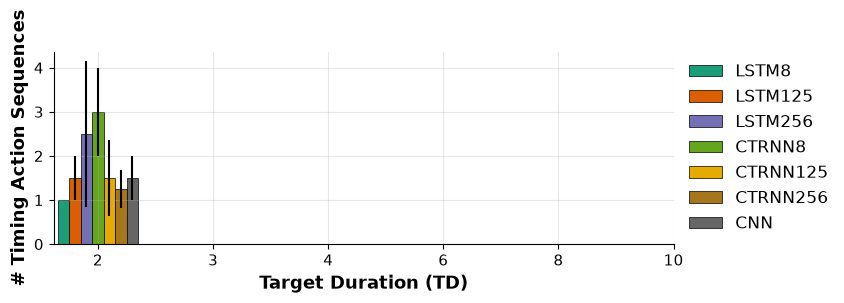

In [44]:
# action seq 
results_list = [
    performance_history_df8,
    performance_history_df125,
    performance_history_df256,
    performance_history_df_ctrnn8,
    performance_history_df_ctrnn125,
    performance_history_df_ctrnn256,
    performance_history_df_cnn
]

model_names = [
    "LSTM8",
    "LSTM125",
    "LSTM256",
    "CTRNN8",
    "CTRNN125",
    "CTRNN256",
    "CNN"
]

all_results_df = pd.concat(results_list, ignore_index=True)

plt.figure(figsize=(8,2.5))

cmap = plt.cm.Dark2
colors = [cmap(i) for i in np.linspace(0,1, len(model_names))]

duration_list_id = "2-4-6-8-10"
cl_stage = 1
x = np.arange(len(TDs))
width = 0.7 / len(model_names)


for i, model in enumerate(model_names):
    model_data = all_results_df[all_results_df["model"]==model]
    model_data = model_data[(model_data["duration_list_id"]==duration_list_id) & (model_data["Cl_stage"]==cl_stage)]
    act_seq_count_mean = {}
    act_seq_count_sd = {}
    for j, td in enumerate(TDs):
    
        model_data_filtered = model_data[model_data["TD"] == td]
        model_data_filtered["timing_action_flatten"] = model_data_filtered["timing_actions"].apply(lambda x:
                                                                                                   tuple(np.asarray(x).flatten().tolist()))
        act_seq_count_mean[td] = model_data_filtered.groupby(["log"])["timing_action_flatten"].nunique().values.mean()
        act_seq_count_sd[td] = model_data_filtered.groupby("log")["timing_action_flatten"].nunique().values.std()
    
    plt.bar(
    x + (i - (len(model_names) - 1) / 2) * width,
    [act_seq_count_mean[td] for td in TDs],
    width=width,
    yerr=[act_seq_count_sd[td] for td in TDs],
    color=colors[i],
    label=model,
    edgecolor="black",
    linewidth=0.5
)

    # break

# # Styling
# plt.xticks(list(act_seq_count_td.keys()), rotation=45)
plt.xticks(
    x,
    TDs
)
plt.xlabel("Target Duration (TD)", fontweight="bold")
plt.ylabel("# Timing Action Sequences", fontweight="bold")
# plt.title("Sequence Diversity vs LSTM Capacity", fontsize=14)

plt.grid(True, alpha=0.3)
plt.legend(
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
# plt.tight_layout()

# plt.savefig("FI_num_timing_actions.pdf", bbox_inches='tight')
plt.show()

/tmp/ipykernel_173/3924017267.py:59: RuntimeWarning: Mean of empty slice
  act_seq_count_mean[td] = model_data_filtered.groupby(["log"])["timing_action_flatten"].nunique().values.mean()
/opt/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_173/3924017267.py:59: RuntimeWarning: Mean of empty slice
  act_seq_count_mean[td] = model_data_filtered.groupby(["

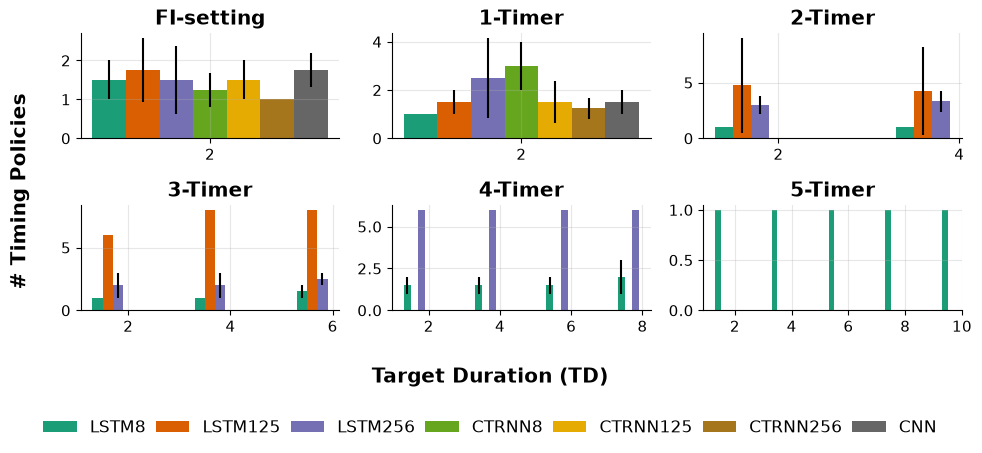

In [66]:
# action seq 
results_list = [
    performance_history_df8,
    performance_history_df125,
    performance_history_df256,
    performance_history_df_ctrnn8,
    performance_history_df_ctrnn125,
    performance_history_df_ctrnn256,
    performance_history_df_cnn
]

model_names = [
    "LSTM8",
    "LSTM125",
    "LSTM256",
    "CTRNN8",
    "CTRNN125",
    "CTRNN256",
    "CNN"
]

all_results_df = pd.concat(results_list, ignore_index=True)

cmap = plt.cm.Dark2
colors = [cmap(i) for i in np.linspace(0, 1, len(model_names))]

duration_list_id = "2-4-6-8-10"
cl_stages = range(0, 6)  # 0 to 5

fig, axes = plt.subplots(2, 3, figsize=(10, 4), sharey=False)
axes = axes.flatten()

for ax_idx, cl_stage in enumerate(cl_stages):
    ax = axes[ax_idx]

    # Filter TDs that actually have data for this CL stage
    stage_df = all_results_df[
        (all_results_df["duration_list_id"] == duration_list_id) &
        (all_results_df["Cl_stage"] == cl_stage)
    ]
    valid_TDs = [td for td in TDs if td in stage_df["TD"].unique()]

    x = np.arange(len(valid_TDs))
    width = 0.7 / len(model_names)

    for i, model in enumerate(model_names):
        model_data = all_results_df[all_results_df["model"] == model]
        model_data = model_data[
            (model_data["duration_list_id"] == duration_list_id) &
            (model_data["Cl_stage"] == cl_stage)
        ]
        act_seq_count_mean = {}
        act_seq_count_sd = {}
        for td in valid_TDs:
            model_data_filtered = model_data[model_data["TD"] == td]
            model_data_filtered["timing_action_flatten"] = model_data_filtered["timing_actions"].apply(
                lambda x: tuple(np.asarray(x).flatten().tolist())
            )
            act_seq_count_mean[td] = model_data_filtered.groupby(["log"])["timing_action_flatten"].nunique().values.mean()
            act_seq_count_sd[td] = model_data_filtered.groupby("log")["timing_action_flatten"].nunique().values.std()

        ax.bar(
            x + (i - (len(model_names) - 1) / 2) * width,
            [act_seq_count_mean[td] for td in valid_TDs],
            width=width,
            yerr=[act_seq_count_sd[td] for td in valid_TDs],
            color=colors[i],
            label=model,
            # edgecolor="black",
            linewidth=0.5
        )

    ax.set_xticks(x)
    ax.set_xticklabels(valid_TDs)
    # ax.set_xlabel("Target Duration (TD)", fontweight="bold")
    # ax.set_ylabel("# Timing Action Sequences", fontweight="bold")
    if cl_stage !=0:
        ax.set_title(f"{cl_stage}-Timer",fontweight="bold")
    else:
        ax.set_title(f"FI-setting",fontweight="bold")
    ax.grid(True, alpha=0.3)

# Single shared legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, frameon=False, loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.supylabel("# Timing Policies", fontweight="bold")
fig.supxlabel("Target Duration (TD)", fontweight="bold")
leg = fig.legend(
    handles,
    labels ,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=len(labels),
    # ncol=2,
    frameon=False,
    columnspacing=0.6
)
plt.tight_layout()
plt.savefig("multitimer_exact_num_timing_actions.pdf", bbox_inches='tight')
plt.show()

# Training time steps CL

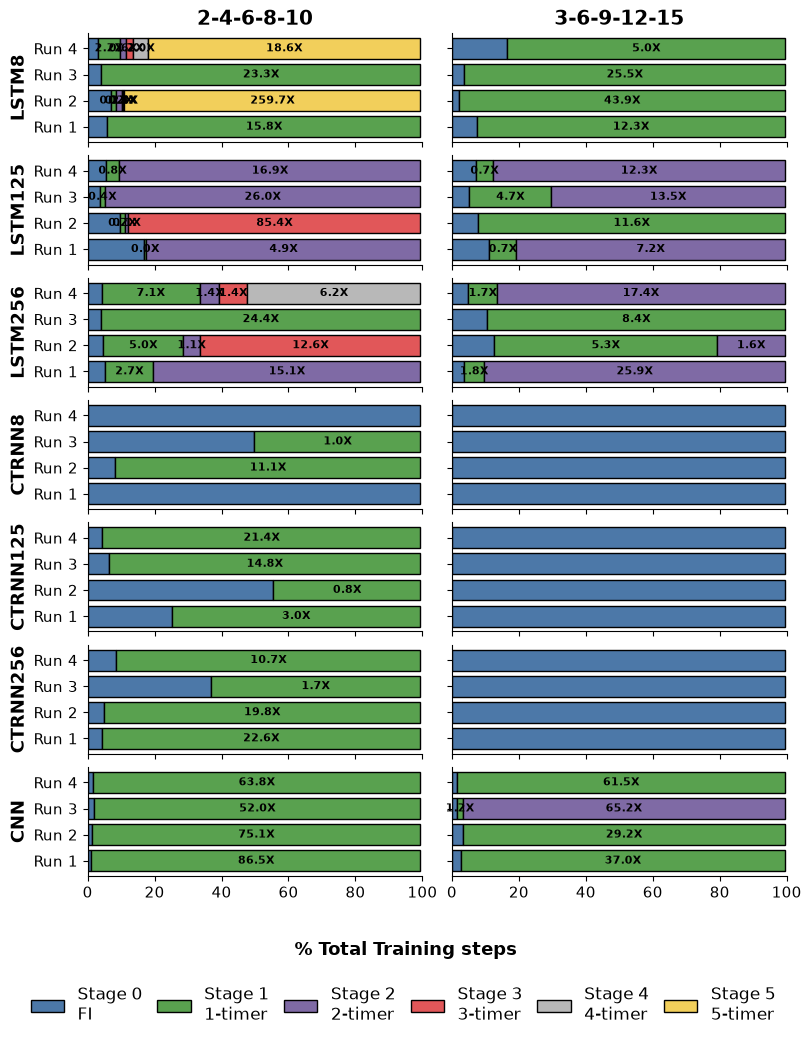

In [67]:

results = {
    "LSTM8": min_training_timesteps8,
    "LSTM125": min_training_timesteps125,
    "LSTM256": min_training_timesteps256,
    "CTRNN8": min_training_timesteps_ctrnn8,
    "CTRNN125": min_training_timesteps_ctrnn125,
    "CTRNN256": min_training_timesteps_ctrnn256,
    "CNN": min_training_timesteps_cnn
}
training_timesteps_rows = []
colors = [
    "#4C78A8", "#59A14F",  "#7F6AA5",
    "#E15759", "#B8B8B8",
    "#F2CF5B",
]
models = list(results.keys())
# anchors = list(results[models[0]].keys())
td_list = ['2-4-6-8-10','3-6-9-12-15']
max_training_ts = 1760000  # <-- total training timesteps

fig, axes = plt.subplots(
    len(models),          # rows
    len(td_list),         # columns
    figsize=(8,9
            ),
    squeeze=False,
    sharex=True,
    constrained_layout=True
)

for row, model in enumerate(models):

    for col, anchor in enumerate(td_list):

        ax = axes[row, col]

        runs = sorted(results[model][anchor].keys())
        y = np.arange(len(runs))

        left = np.zeros(len(runs))
        values_stages = {
                0: [],
                1: [],
                2: [],
                3: [],
                4: [],
                5: []
            } 
    
        perc_increase_stages = {
                0: [],
                1: [],
                2: [],
                3: [],
                4: [],
                5: []
            } 

        for stage in range(6):

            widths = []
            perc_increase= []

            for run in runs:

                values = np.array(results[model][anchor][run])

                values_stages[stage].append(values[stage])
                    
                learning_time = np.diff(
                    np.insert(values, 0, 0)
                ).astype(float)
                
                learning_time = [lt if lt>0 else np.nan for lt in learning_time]
                

                if stage >= len(learning_time):
                    widths.append(0)
                    continue

                # if learning_time[stage] <= 0:
                #     learning_time[stage] = np.nan

                # Convert stage duration to percentage of total training
                widths.append(100 * learning_time[stage] / max_training_ts)

                if stage ==2:
                    perc_increase.append( learning_time[stage] / learning_time[stage-2])
                elif stage > 0:
                    perc_increase.append( learning_time[stage] / learning_time[stage-1])
                else:
                    perc_increase.append(np.nan)

            if stage > 0:
                perc_increase_stages[stage] = perc_increase
            else:
                perc_increase_stages[stage] = widths # significance test - for stage one instead of xtimes previous stage, get % timesteps needed for stage 1 
   

            if stage == 0:
                leg_label = f"Stage {stage} \nFI"
            else:
                leg_label = f"Stage {stage} \n{stage}-timer" 
            ax.barh(
                y,
                widths,
                left=left,
                color=colors[stage],
                edgecolor="black",
                linewidth=1,
                label=leg_label if (row == 0 and col == 0) else None,
            )

            for run_idx, (width, perc) in enumerate(
                zip(widths, perc_increase)
            ):

                if (
                    np.isnan(perc)
                    or width <= 0
                ):
                    continue

                # Center of this bar segment
                x_text = (
                    left[run_idx]
                    + width / 2
                )

                ax.text(
                    x_text,
                    y[run_idx],
                    f"{perc:.1f}X",
                    ha="center",
                    va="center",
                    fontsize=8,
                    fontweight="bold",
                    color="black"
                )



            left += np.nan_to_num(widths)

        ax.set_yticks(y)

        if col == 0:
            ax.set_yticklabels([f"Run {r}" for r in runs])
            ax.set_ylabel(model, fontweight="bold")
        else:
            ax.set_yticklabels([])

        if row == 0:
            ax.set_title(anchor, fontweight="bold")

        # if row == len(models) - 1:
        #     ax.set_xlabel("% Total Training")

        ax.set_xlim(0, 100)
        for run in range(len(runs)):
            if "CTRNN" in model:
                arch = "CTRNN"
                mem_size = int(model[5:])
            elif "LSTM" in model:
                arch = "LSTM"
                mem_size = int(model[4:])
            else:
                arch="CNN"
                mem_size=-1
            training_timesteps_rows.append({"architecture":arch, "memory_size":mem_size, "model":model,"anchor":anchor, "run":run, 
                                           "stage0":values_stages[0][run], "stage1":values_stages[1][run], "stage2":values_stages[2][run],
                                            "stage3":values_stages[3][run], "stage4":values_stages[4][run], "stage5":values_stages[5][run],
                                           "stage0_pct": perc_increase_stages[0][run], "stage1-0":perc_increase_stages[1][run], 
                                            "stage2-1":perc_increase_stages[2][run], "stage3-2":perc_increase_stages[3][run],
                                            "stage4-3":perc_increase_stages[4][run], "stage5-4":perc_increase_stages[5][run]})

        # ax.grid(axis="x", alpha=0.3)

# axes[0, 0].legend(title="Curriculum stage", ncols=3, loc="lower center", )
fig.supxlabel("% Total Training steps", y =-0.06, fontsize=13, fontweight="bold")
# plt.tight_layout()
handles, labels_ = axes[0, 0].get_legend_handles_labels()

leg = fig.legend(
    handles,
    labels_ ,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=len(labels_),
    # ncol=2,
    frameon=False,
    columnspacing=0.6
)

plt.savefig("multitimer_scalability_exact_supp.pdf", bbox_inches='tight')
        
plt.show()
training_timestep_df = pd.DataFrame(training_timesteps_rows)

In [17]:
!pip install -U tensorboard setuptools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 117.9 MB/s  0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.20.0
    Uninstalling tensorboard-2.20.0:
      Successfully uninstalled tensorboard-2.20.0


In [15]:
%load_ext tensorboard

In [18]:
tb_event_file = event_files_ctrnn125['4-6-8-10-12'][1]
%tensorboard --logdir $tb_event_file

In [29]:
min_training_timesteps125, min_training_timesteps_ctrnn125

({'2-4-6-8-10': {1: [295000, 308000, 1750000, 0, 0, 0],
   2: [168000, 195000, 213000, 1750000, 0, 0],
   3: [64000, 89000, 1750000, 0, 0, 0],
   4: [94000, 166000, 1750000, 0, 0, 0]}},
 {'2-4-6-8-10': {1: [441000, 1750000, 0, 0, 0, 0],
   2: [977000, 1750000, 0, 0, 0, 0],
   3: [111000, 1750000, 0, 0, 0, 0],
   4: [78000, 1750000, 0, 0, 0, 0]}})

In [30]:
tb_event_file = event_files125['2-4-6-8-10'][4]
%tensorboard --logdir $tb_event_file

In [7]:
# # numtimers 1 - evn0, 2, , 3-env1, 4-env2, 5-env3, 6-env4, 7-env5
# numtimers_envlabels = {1:0,2:0,3:1,4:2,5:3,6:4,7:5}
# oven_duration_list = [4,10,15,20,25]
# duration_list_id = "-".join(map(str, oven_duration_list))
# lstm_size = 125
# ent_coeff = 0
# timestep = 200
# g=0.99
# rows = []
# rows_traj = []
# overcooked_buffer =2
# models_folder = "/project_ghent/chronocooked/singleagent/train/multitimer_cl_tp_modelsv1"
# # for target_duration in oven_duration_list:
# for log in [1,2]:
#     for num_timers in range(1,len(oven_duration_list)+1):
#         if num_timers >= 2:
#             continue
#         # add log as param 
#         if lstm_size == None:
#             model_save_path = f"{models_folder}/v3_cl_multitimer{duration_list_id}_tp_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_mlp64_gamma{g}_buffer{overcooked_buffer}_logs{log}/"
#         else:  
#             model_save_path = f"{models_folder}/v3_cl_multitimer{duration_list_id}_tp_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_sharedlstm{lstm_size}_mlp64_gamma{g}_buffer{overcooked_buffer}_logs{log}/"

#         model_files = os.listdir(model_save_path)
#         max_training_ts = max([int(model_file.split("env")[1].split("_")[1])  if ("env" in model_file) and (model_file.split("env")[1].split("_")[0].isdigit()) and (int(model_file.split("env")[1].split("_")[0]) == numtimers_envlabels[num_timers]) else 0 for model_file in model_files])
#         if max_training_ts == 0:
#             print("No training timesteps found for num_timer", num_timers)
#             continue
#         if lstm_size == None:
#             model = PPO.load(f"{model_save_path}/rl_model_env{numtimers_envlabels[num_timers]}_{max_training_ts}_steps.zip")
#         else:
#             model = RecurrentPPO.load(f"{model_save_path}/rl_model_env{numtimers_envlabels[num_timers]}_{max_training_ts}_steps.zip")
#         for target_duration in oven_duration_list:
#             env_test = MultiTimeProduction( oven_duration = target_duration, max_timesteps=timestep, num_timers=num_timers,
#                                           undercooked_possible=True, overcooked_buffer=overcooked_buffer)
#             model.set_env(env_test)
#             for s_i, seed in enumerate(seeds.values()):
#                 obs, _ = env_test.reset(seed=seed)
#                 visual_obs = np.sum(obs,axis=2)
#                 obs_concat = [visual_obs]
#                 act_concat = []
#                 reward_concat = []
#                 adj_oven = []
#                 oven_timers = []
#                 # print("oven timers", env_test.oven1_timer, env_test.oven2_timer)
#                 rewards=0
#                 states = None
#                 for i in range(timestep + 2):
#                     # obs = obs + 300
#                     action, states = model.predict(obs, state=states, deterministic=True) 
#                     act_concat.append(action)
#                     adjacent_cells = env_test.get_adjacent_cells(env_test.agent_position)
#                     if env_test.oven_pos in adjacent_cells.keys():
#                         adj_oven.append(1)
#                     else:
#                         adj_oven.append(1)
#                     # print(visual_obs)
#                     # print("action",action)
#                     oven_timers.append(env_test.oven_timer)
#                     obs, reward, done, _ ,_= env_test.step(action)
#                     visual_obs = np.sum(obs,axis=2)
#                     obs_concat.append(visual_obs)

                
#                     # print("reward",reward)
#                     # print("oven_off_time",env_test.oven_off_time)
                    
#                     rewards += reward
#                     reward_concat.append(reward)
#                     if done:
                        
#                         act_concat.append(0)
#                         reward_concat.append(0)

                        
#                         rows.append({"TD":target_duration, "p_id":log, "seed":s_i,
#                                      "num_timers":num_timers,"reward":reward, "oven_off_time":env_test.oven_off_time,
#                                     "delta_oven_off":env_test.oven_off_time - target_duration})
#                         rows_traj.append({"TD":target_duration, "p_id":log, "seed":s_i,"num_timers":num_timers,"reward":reward,
#                                          "act_concat":act_concat,"obs_concat":obs_concat,"reward_concat":reward_concat})
#                         print("oven duration", env_test.oven_duration,"rewards",rewards)
#                         obs,_ = env_test.reset()
#                         break

#             # if target_duration==24:
#                 # break
#         # break
# task_performance = pd.DataFrame(rows)

FileNotFoundError: [Errno 2] No such file or directory: '/project_ghent/chronocooked/singleagent/train/multitimer_cl_tp_modelsv1/v3_cl_multitimer4-10-15-20-25_tp_cnnout64_ts200_entcoef0_nepoch20_sharedlstm125_mlp64_gamma0.99_buffer2_logs1/'

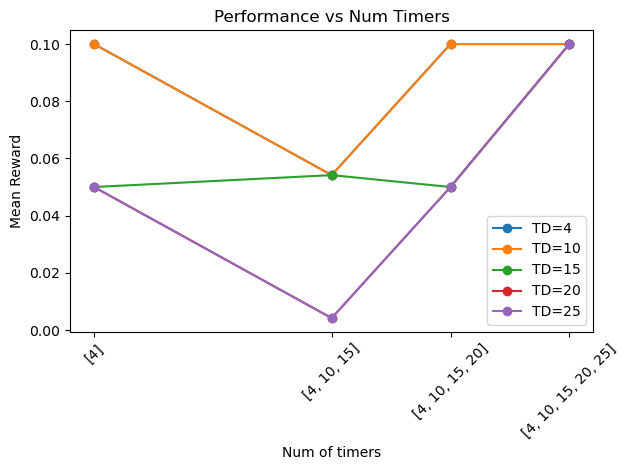

In [48]:
# average reward across td by num_timers
df_mean = task_performance.groupby(["num_timers", "TD"])["reward"].mean().reset_index()


pivot_df = df_mean.pivot(index="num_timers", columns="TD", values="reward")


plt.figure()

for td in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[td], marker='o', label=f"TD={td}")

x_vals = pivot_df.index.tolist()
x_labels = [str(oven_duration_list[:n]) for n in x_vals]

plt.xticks(x_vals, x_labels, rotation=45)

plt.xlabel("Num of timers")
plt.ylabel("Mean Reward")
plt.title("Performance vs Num Timers")
plt.legend()
plt.tight_layout()

plt.show()

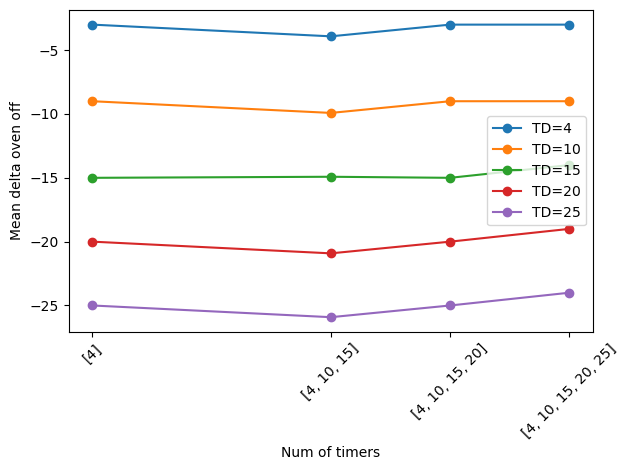

In [49]:
# average oven off across td by num_timers 
task_performance["delta_oven_off"] = task_performance.apply(lambda x: x["oven_off_time"]-x["TD"], axis=1)
df_mean = task_performance.groupby(["num_timers", "TD"])["delta_oven_off"].mean().reset_index()


pivot_df = df_mean.pivot(index="num_timers", columns="TD", values="delta_oven_off")


plt.figure()

for td in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[td], marker='o', label=f"TD={td}")

x_vals = pivot_df.index.tolist()
x_labels = [str(oven_duration_list[:n]) for n in x_vals]

plt.xticks(x_vals, x_labels, rotation=45)

plt.xlabel("Num of timers")
plt.ylabel("Mean delta oven off")
plt.legend()
plt.tight_layout()

plt.show()

In [60]:
# time steps needed for 1st timer 
# numtimers 1 - evn0, 2, , 3-env1, 4-env2, 5-env3, 6-env4, 7-env5
numtimers_envlabels = {1:0,2:0,3:1,4:2,5:3,6:4,7:5}
oven_duration_list = [4,10,15,20,25]
duration_list_id = "-".join(map(str, oven_duration_list))
lstm_size = 256
ent_coeff = 0
timestep = 200
g=0.99
rows = []
rows_traj = []
overcooked_buffer =2
models_folder = "/project_ghent/chronocooked/singleagent/train/multitimer_cl_tp_modelsv1"
# for target_duration in oven_duration_list:
for log in [1,2]:
    for num_timers in range(1,len(oven_duration_list)+1):
        if num_timers >= 2:
            continue
        # add log as param 
        if lstm_size == None:
            model_save_path = f"{models_folder}/v3_cl_multitimer{duration_list_id}_tp_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_mlp64_gamma{g}_buffer{overcooked_buffer}_logs{log}/"
        else:  
            model_save_path = f"{models_folder}/v3_cl_multitimer{duration_list_id}_tp_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_sharedlstm{lstm_size}_mlp64_gamma{g}_buffer{overcooked_buffer}_logs{log}/"

        model_files = os.listdir(model_save_path)
        max_training_ts = max([int(model_file.split("env")[1].split("_")[1])  if ("env" in model_file) and (model_file.split("env")[1].split("_")[0].isdigit()) and (int(model_file.split("env")[1].split("_")[0]) == numtimers_envlabels[num_timers]) else 0 for model_file in model_files])
        if max_training_ts == 0:
            print("No training timesteps found for num_timer", num_timers)
            continue
        print("max training timestep",max_training_ts, "log", log, "num timers", num_timers)
        if lstm_size == None:
            model = PPO.load(f"{model_save_path}/rl_model_env{numtimers_envlabels[num_timers]}_{max_training_ts}_steps.zip")
        else:
            model = RecurrentPPO.load(f"{model_save_path}/rl_model_env{numtimers_envlabels[num_timers]}_{max_training_ts}_steps.zip")
        for target_duration in oven_duration_list[:1]:
            env_test = MultiTimeProduction( oven_duration = target_duration, max_timesteps=timestep, num_timers=num_timers,
                                          undercooked_possible=True, overcooked_buffer=overcooked_buffer)
            model.set_env(env_test)
            for s_i, seed in enumerate(seeds.values()):
                obs, _ = env_test.reset(seed=seed)
                visual_obs = np.sum(obs,axis=2)
                obs_concat = [visual_obs]
                act_concat = []
                reward_concat = []
                adj_oven = []
                oven_timers = []
                # print("oven timers", env_test.oven1_timer, env_test.oven2_timer)
                rewards=0
                states = None
                for i in range(timestep + 2):
                    # obs = obs + 300
                    action, states = model.predict(obs, state=states, deterministic=True) 
                    act_concat.append(action)
                    adjacent_cells = env_test.get_adjacent_cells(env_test.agent_position)
                    if env_test.oven_pos in adjacent_cells.keys():
                        adj_oven.append(1)
                    else:
                        adj_oven.append(1)
                    # print(visual_obs)
                    # print("action",action)
                    oven_timers.append(env_test.oven_timer)
                    obs, reward, done, _ ,_= env_test.step(action)
                    visual_obs = np.sum(obs,axis=2)
                    obs_concat.append(visual_obs)

                
                    # print("reward",reward)
                    # print("oven_off_time",env_test.oven_off_time)
                    
                    rewards += reward
                    reward_concat.append(reward)
                    if done:
                        
                        act_concat.append(0)
                        reward_concat.append(0)

                        
                        rows.append({"TD":target_duration, "p_id":log, "seed":s_i,
                                     "num_timers":num_timers,"reward":reward, "oven_off_time":env_test.oven_off_time,
                                    "delta_oven_off":env_test.oven_off_time - target_duration})
                        rows_traj.append({"TD":target_duration, "p_id":log, "seed":s_i,"num_timers":num_timers,"reward":reward,
                                         "act_concat":act_concat,"obs_concat":obs_concat,"reward_concat":reward_concat})
                        # print("oven duration", env_test.oven_duration,"rewards",rewards)
                        obs,_ = env_test.reset()
                        break

            # if target_duration==24:
                # break
        # break
task_performance = pd.DataFrame(rows)
task_performance

max training timestep 240000 log 1 num timers 1
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
max training timestep 200000 log 2 num timers 1
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


,TD,p_id,seed,num_timers,reward,oven_off_time,delta_oven_off
0,4,1,0,1,0.0,1,-3
1,4,1,1,1,0.1,1,-3
2,4,1,2,1,1.0,4,0
3,4,1,3,1,0.1,1,-3
4,4,1,4,1,1.0,3,-1
5,4,1,5,1,1.0,2,-2
6,4,1,6,1,0.0,-1,-5
7,4,1,7,1,1.0,2,-2
8,4,1,8,1,0.1,-1,-5
9,4,1,9,1,1.0,2,-2
